# California Housing Analysis

## Problem Statement
The objective is to perform a comprehensive analysis of the California Housing dataset to prepare it for Machine Learning tasks.
We need to understand the data distribution, detect and handle outliers to ensure data quality, and apply feature scaling
to normalize the range of independent variables.

## Steps to Solve the Problem
1.  **Data Loading**: Fetch the dataset from Scikit-Learn's repository.
2.  **Exploratory Data Analysis (EDA)**: Understand the data shape, types, and statistics.
3.  **Outlier Detection**:
    - Sub-problem 1: Identify extreme values using Percentiles.
    - Sub-problem 2: Detect outliers using the Interquartile Range (IQR) method.
    - Sub-problem 3: Detect outliers using Z-Score.
    - Sub-problem 4: Identify logical inconsistencies (e.g., Bedrooms > Rooms).
4.  **Data Cleaning**: Remove the identified outliers to improve model quality.
5.  **Feature Engineering**: 
    - Separate Features (X) and Target (y).
    - Identify Numerical vs Categorical columns.
6.  **Feature Scaling**: Apply StandardScaler to numerical features to mean=0, std=1.

## Expected Output
- A clean, scaled dataset ready for training. (Mean approx 0, Std approx 1).
- Console logs detailing the number of outliers found and removed.
- Statistical summaries before and after scaling to verify transformation.

### 1. Import Libraries

**2.1 Definition**: Import the 'fetch_california_housing' function.
**2.2 Why**: This function provides a direct and standardized way to download the California Housing dataset.
**2.3 When**: At the start of the project when data acquisition is needed.
**2.4 Where**: Import section.
**2.5 How to use**: `from sklearn.datasets import fetch_california_housing`.
**2.6 How it works**: It downloads the data from a remote repository or loads it from a local cache.
**2.7 Output**: A function object.

**2.1 Definition**: Import Pandas library.
**2.2 Why**: For data manipulation and analysis using DataFrames (tabular data structure).
**2.3 When**: Whenever we deal with structured data (rows and columns).
**2.4 Where**: Import section.
**2.5 How to use**: `import pandas as pd`.
**2.6 How it works**: Loads the library into memory and aliases it as 'pd' for convenience.
**2.7 Output**: Module object 'pd'.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import ssl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

### 2. Helper Function: Detect Outliers (IQR)

**2.1 Definition**: Function to identify outliers using IQR.
**2.2 Why**: To isolate data points that are statistically far from the central distribution.
**2.3 When**: Data Cleaning phase.
**2.4 Where**: Global scope.
**2.5 How to use**: `detect_outliers_iqr(df, 'Column')`.
**2.6 How it works**: Calculates Q1, Q3, spreads fences 1.5xIQR out, and checks for violations.
**2.7 Output**: DataFrame of outlier rows.

**Arguments**:
*   **3.1 Argument `df`**: The Pandas DataFrame containing the data.
*   **3.1 Argument `column`**: The name of the column to check.

In [2]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

### 3. Helper Function: Remove Outliers (IQR)

**2.1 Definition**: Function to filter out outliers.
**2.2 Why**: To sanitize the dataset for better model performance.
**2.3 When**: Data Cleaning phase.
**2.5 How to use**: `df = remove_outliers_iqr(df, 'Column')`.
**2.6 How it works**: Returns only the rows that are within the fences.
**2.7 Output**: Cleaned DataFrame.

In [3]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

### 4. Data Loading and Preparation

**2.1 Definition**: Setup SSL and Fetch Data.
**2.2 Why**: Fix potential network issues and load the raw data.
**2.3 When**: Step 1 of execution.
**2.5 How to use**: Call fetch function.
**2.6 How it works**: Downloads data to memory.
**2.7 Output**: DataFrame `df` ready for analysis.

In [4]:
# Setup SSL
ssl._create_default_https_context = ssl._create_unverified_context

# Fetch Data
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

# Create Working DataFrame
df = X.copy()
df['MedHouseValue'] = y
print(f"Dataset shape: {df.shape}")

Dataset shape: (20640, 9)


### 5. Exploratory Data Analysis (EDA)

**2.1 Definition**: Initial Inspection.
**2.2 Why**: To understand data structure, missing values, and statistics.
**2.3 When**: Step 2 (EDA).
**2.5 How to use**: `head`, `describe`, `info`.
**2.6 How it works**: Pandas internal summarization.
**2.7 Output**: Statistical tables and info logs.

In [7]:
print("First five rows of the dataset:")
print(df.head())

print("\nSummary statistics of the dataset:")
print(df.describe())

print("\nDataFrame info:")
print(df.info())

print("\nMissing values in the dataset:")
print(df.isnull().sum())

First five rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  

Summary statistics of the dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473

### 6. Outlier Analysis

**2.1 Definition**: Comprehensive Outlier Checks.
**2.2 Why**: To identify bad data points using Percentiles, IQR, and Logic.
**2.3 When**: Step 3 (Outlier Detection).
**2.5 How to use**: Quantile functions and logical filters.
**2.6 How it works**: Applies multiple statistical checks.
**2.7 Output**: Lists of detected outliers.

In [8]:
# Method 1: Percentiles
print("\n=== METHOD 1: Extreme Values (Percentiles) ===")
print(df['MedHouseValue'].quantile([0.01, 0.25, 0.5, 0.75, 0.99]))

# Method 2: IQR
print("\n=== METHOD 2: IQR Method ===")
iqr_outliers = detect_outliers_iqr(df, 'MedHouseValue')
print(f"Outliers detected: {len(iqr_outliers)}")

# Method 5: Logical
print("\n=== METHOD 5: Logical Inconsistencies ===")
logical_issues = df[df['AveBedrms'] > df['AveRooms']]
print(f"Records where bedrooms > rooms: {len(logical_issues)}")


=== METHOD 1: Extreme Values (Percentiles) ===
0.01    0.50000
0.25    1.19600
0.50    1.79700
0.75    2.64725
0.99    5.00001
Name: MedHouseValue, dtype: float64

=== METHOD 2: IQR Method ===
Outliers detected: 1071

=== METHOD 5: Logical Inconsistencies ===
Records where bedrooms > rooms: 0


### 7. Visualization

**2.1 Definition**: Boxplot Visualization.
**2.2 Why**: To visually identify the spread and outliers in key columns.
**2.3 When**: EDA/Outlier phase.
**2.5 How to use**: `matplotlib.pyplot`.
**2.6 How it works**: Renders graphics.
**2.7 Output**: A plot.

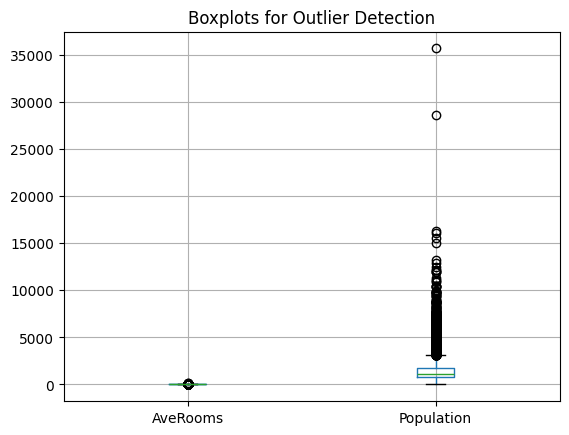

In [9]:
plt.figure()
df.boxplot(column=['AveRooms', 'Population'])
plt.title("Boxplots for Outlier Detection")
plt.show()

### 8. Data Cleaning

**2.1 Definition**: Outlier Removal.
**2.2 Why**: To clean the dataset for modeling.
**2.3 When**: Step 4.
**2.5 How to use**: `remove_outliers_iqr`.
**2.6 How it works**: Filters the dataframe.
**2.7 Output**: Reduced DataFrame size.

In [10]:
df_cleaned = remove_outliers_iqr(df, 'AveRooms')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Population')

print("\nShape before outlier removal:", df.shape)
print("Shape after outlier removal:", df_cleaned.shape)


Shape before outlier removal: (20640, 9)
Shape after outlier removal: (18957, 9)


### 9. Feature Scaling

**2.1 Definition**: Standardization (Z-score Scaling).
**2.2 Why**: To ensure all features contribute equally to the model (Mean=0, Std=1).
**2.3 When**: Step 6 (Pre-processing).
**2.5 How to use**: `StandardScaler`.
**2.6 How it works**: `(x - mean) / std`.
**2.7 Output**: Scaled DataFrame.

In [11]:
print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

# Separate Target
features = df_cleaned.drop(columns=['MedHouseValue'])
target = df_cleaned['MedHouseValue']
numerical_columns = features.select_dtypes(include=[np.number]).columns.tolist()

# Apply Scaling
print("\n--- APPLYING STANDARDSCALER ---")
scaler = StandardScaler()
scaled_features_array = scaler.fit_transform(features[numerical_columns])

df_scaled = pd.DataFrame(
    scaled_features_array,
    columns=numerical_columns,
    index=features.index
)
df_scaled['MedHouseValue'] = target.values

print("\n--- FINAL SCALED DATASET ---")
print(f"Shape: {df_scaled.shape}")
print(df_scaled.head())


FEATURE SCALING

--- APPLYING STANDARDSCALER ---

--- FINAL SCALED DATASET ---
Shape: (18957, 9)
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.508300  0.932269  1.526644  -0.332234   -1.437429 -0.343469  1.042672   
1  2.495067 -0.689682  0.874013  -0.784887    1.823385 -0.758458  1.033319   
2  1.914593  1.824341  2.667459   0.100439   -1.164518 -0.113771  1.028642   
3  1.017027  1.824341  0.505888   0.097066   -1.067274 -0.350555  1.028642   
4  0.017933  1.824341  0.912259   0.166989   -1.056295 -0.691770  1.028642   

   Longitude  MedHouseValue  
0  -1.307633          4.526  
1  -1.302641          3.585  
2  -1.312624          3.521  
3  -1.317616          3.413  
4  -1.317616          3.422  


### 10. Verification

**2.1 Definition**: Statistical Check.
**2.2 Why**: To verify the scaling worked as intended.
**2.3 When**: Final step.
**2.5 How to use**: `mean()` and `std()`.
**2.6 How it works**: Checks column statistics.
**2.7 Output**: Means near 0, Stds near 1.

In [12]:
print("\n--- SCALING VERIFICATION ---")
print(f"Mean of scaled features (Should be ~0):\n{df_scaled[numerical_columns].mean()}")
print(f"\nStd of scaled features (Should be ~1):\n{df_scaled[numerical_columns].std()}")


--- SCALING VERIFICATION ---
Mean of scaled features (Should be ~0):
MedInc        4.797672e-17
HouseAge      0.000000e+00
AveRooms      1.319360e-16
AveBedrms     1.286376e-15
Population   -1.049491e-16
AveOccup      2.548763e-16
Latitude      2.398836e-17
Longitude    -3.754178e-15
dtype: float64

Std of scaled features (Should be ~1):
MedInc        1.000026
HouseAge      1.000026
AveRooms      1.000026
AveBedrms     1.000026
Population    1.000026
AveOccup      1.000026
Latitude      1.000026
Longitude     1.000026
dtype: float64
